In [ ]:
#Exploratory Data Analysis - Table, Charts
#Excel - Value counts etc.. Head

In [1]:
import pandas as pd 
import numpy as np

In [ ]:
data = pd.read_csv("Data/companytest.csv",na_values=['','#NA',"#N/A","N/A","n/a","NA","na","-1.#IND","-1.#QNAN","-NaN",
"-nan","#N/A N/A","#N/A","#NA","#NULL","N/A N/A","NULL","NaN","n/a N/A","nan","null"])

In [ ]:
pd.read_csv?

In [ ]:
#'','#NA',"#N/A","N/A","n/a","NA","na","-1.#IND","-1.#QNAN","-NaN",
#"-nan","#N/A N/A","#N/A","#NA","#NULL","N/A N/A","NULL","NaN","n/a N/A","nan","null"

In [3]:
data.head()

,Company,Age,Salary
0,b,40.0,9000000.0
1,d,300.0,1000.0
2,a,30.0,-400.0
3,'a',20.0,NaN
4,c,30.0,NaN


In [5]:
data.isna().sum()

Company    3
Age        4
Salary     7
dtype: int64

In [6]:
data.shape

(33, 3)

In [ ]:
How to handle Missing Values in Data Preprocessing?

1. Remove the rows with missing values (Count of rows is less than 5% of total rows)
2. Impute the missing values with mean, median, mode, or any other statistical measure (Count of rows is more than 5% of total rows)

In [7]:
data.dropna(axis=0, inplace=True)

In [ ]:
data.head()

,Company,Age,Salary
0,b,40.0,9000000.0
1,d,300.0,1000.0
2,a,30.0,-400.0
5,'a',35.0,2300.0
6,c,40.0,3000.0


In [9]:
data.shape

(21, 3)

In [ ]:
data.dropna(subset=["Company",'Age'], inplace=True)

In [82]:
data = pd.read_csv("Data/companytest.csv",na_values=['','#NA',"#N/A","N/A","n/a","NA","na","-1.#IND","-1.#QNAN","-NaN",
"-nan","#N/A N/A","#N/A","#NA","#NULL","N/A N/A","NULL","NaN","n/a N/A","nan","null"])

In [83]:
data.head()

,Company,Age,Salary
0,b,40.0,9000000.0
1,d,300.0,1000.0
2,a,30.0,-400.0
3,'a',20.0,NaN
4,c,30.0,NaN


In [84]:
data['Age'].fillna(data['Age'].median(), inplace=True)

/var/folders/4n/9tgv1jfx4gd0t44r5_wvrq440000gn/T/ipykernel_67139/913469570.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)


In [85]:
data.isna().sum()

Company    3
Age        0
Salary     7
dtype: int64

In [89]:
data['Salary']  = data['Salary'].apply(lambda x: abs(x) if x < 0 else x)

In [90]:
data['Salary']

0     9000000.0
1        1000.0
2         400.0
3           NaN
4           NaN
5        2300.0
6        3000.0
7        4000.0
8        5000.0
9        6000.0
10       7000.0
11       8000.0
12       9000.0
13          NaN
14       1089.0
15          NaN
16       1234.0
17       3000.0
18       3000.0
19       3030.0
20       5000.0
21          NaN
22          NaN
23       3045.0
24       3184.0
25       4824.0
26       5835.0
27       7084.0
28       8943.0
29       8345.0
30       9284.0
31          NaN
32       2034.0
Name: Salary, dtype: float64

In [88]:
import statistics

In [60]:
statistics.mode(data['Company'])[0]

'b'

In [91]:
data['Company'].value_counts()

Company
b      9
a      9
c      8
'a'    2
d      1
'c'    1
Name: count, dtype: int64

In [92]:
data['Company'] = data['Company'].apply(lambda x: x.replace("'",""))

AttributeError: 'float' object has no attribute 'replace'

In [93]:
data['Company'] = data['Company'].fillna("Unknown")
data['Company'] = data['Company'].apply(lambda x: x.replace("'",""))

In [94]:
data['Company'].value_counts()

Company
a          11
b           9
c           9
Unknown     3
d           1
Name: count, dtype: int64

In [95]:
statistics.mode(data['Company'])[0]

'a'

In [96]:
data['Company'] = data['Company'].apply(lambda x: x.replace("Unknown",statistics.mode(data['Company'])[0]))

In [97]:
data['Company'].value_counts()

Company
a    14
b     9
c     9
d     1
Name: count, dtype: int64

In [98]:
data.head()

,Company,Age,Salary
0,b,40.0,9000000.0
1,d,300.0,1000.0
2,a,30.0,400.0
3,a,20.0,NaN
4,c,30.0,NaN


In [99]:
data['Age'].describe()

count     33.000000
mean      39.939394
std       47.426878
min       18.000000
25%       23.000000
50%       34.000000
75%       37.000000
max      300.000000
Name: Age, dtype: float64

<Axes: ylabel='Age'>

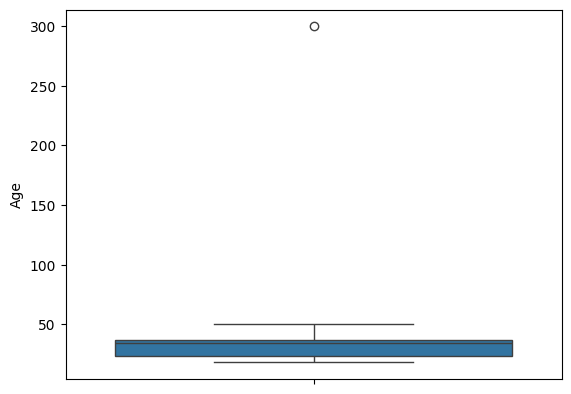

In [100]:
import seaborn as sns 
sns.boxplot(data['Age'])

In [101]:
## Outlier Treatment - Outliers are the values which are far away from the other values in the dataset. Outliers can be treated by using the following methods:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
print(numerical_cols)
for col in numerical_cols:
    print(col)
    Q1 = data[col].quantile(0.25) #Q1
    Q3 = data[col].quantile(0.75) #Q3
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    print(lower_bound)
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])

['Age', 'Salary']
Age
2.0
Salary
-3094.5


<Axes: ylabel='Age'>

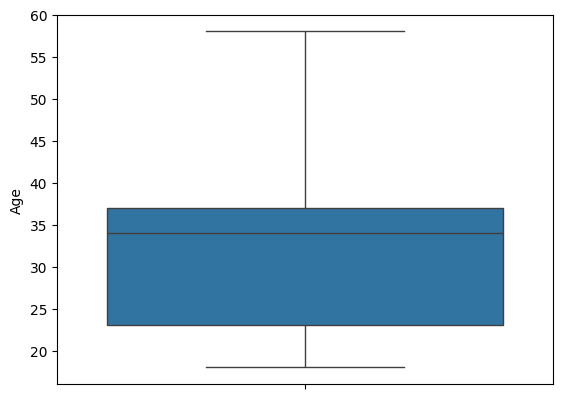

In [102]:
sns.boxplot(data['Age'])

In [104]:
#data['Salary'] = data['Salary'].apply(lambda x: np.nan if x < 0 else x)
data['Salary'].fillna(data['Salary'].mean(), inplace=True)

/var/folders/4n/9tgv1jfx4gd0t44r5_wvrq440000gn/T/ipykernel_67139/1520290428.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Salary'].fillna(data['Salary'].mean(), inplace=True)


In [105]:
data.isna().sum()

Company    0
Age        0
Salary     0
dtype: int64

In [106]:
#Encoding.. 
data

,Company,Age,Salary
0,b,40.0,13157.500000
1,d,58.0,1000.000000
2,a,30.0,400.000000
3,a,20.0,4914.942308
4,c,30.0,4914.942308
5,a,35.0,2300.000000
6,c,40.0,3000.000000
7,a,23.0,4000.000000
8,c,34.0,5000.000000
9,a,34.0,6000.000000


In [ ]:
#Encoding Categorical Variables - Categorical variables are the variables which have a limited number of unique values. Categorical variables can be encoded by using the following methods:
1. Label Encoding - Label Encoding is the process of converting categorical variables into numerical variables. Label Encoding can be done by using the following methods:
   a. Ordinal Encoding - Ordinal Encoding is the process of converting categorical variables into numerical variables by assigning a unique integer to each category. Ordinal Encoding can be done by using the following methods:
      i. LabelEncoder - LabelEncoder is a class in the sklearn library which is used to convert categorical variables into numerical variables. LabelEncoder can be done by using the following methods:
        
2. One Hot Encoding - One Hot Encoding is the process of converting categorical variables into numerical variables by creating a new column for each category. One Hot Encoding can be done by using the following methods: 
    a. get_dummies - get_dummies is a function in the pandas library which is used to convert categorical variables into numerical variables by creating a new column for each category. get_dummies can be done by using the following methods:

In [112]:
pd.get_dummies(data['Company'])

,a,b,c,d
0,False,True,False,False
1,False,False,False,True
2,True,False,False,False
3,True,False,False,False
4,False,False,True,False
5,True,False,False,False
6,False,False,True,False
7,True,False,False,False
8,False,False,True,False
9,True,False,False,False


In [130]:
Company_onehot = pd.get_dummies(data['Company'],dtype=int)

In [131]:
Company_onehot

,a,b,c,d
0,0,1,0,0
1,0,0,0,1
2,1,0,0,0
3,1,0,0,0
4,0,0,1,0
5,1,0,0,0
6,0,0,1,0
7,1,0,0,0
8,0,0,1,0
9,1,0,0,0


In [134]:
df_transformed = pd.concat([data,Company_onehot],axis = 1)

In [136]:
df_transformed.drop(columns = ['Company'])

,Age,Salary,a,b,c,d
0,40.0,13157.500000,0,1,0,0
1,58.0,1000.000000,0,0,0,1
2,30.0,400.000000,1,0,0,0
3,20.0,4914.942308,1,0,0,0
4,30.0,4914.942308,0,0,1,0
5,35.0,2300.000000,1,0,0,0
6,40.0,3000.000000,0,0,1,0
7,23.0,4000.000000,1,0,0,0
8,34.0,5000.000000,0,0,1,0
9,34.0,6000.000000,1,0,0,0


In [146]:
#Alternate way of Onehot encoding
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
#onehotencoder.fit(data[['Company']])
#onehotencoder.transform(data[['Company']])

encoded_values = onehotencoder.fit_transform(data[['Company']])
encoded_values

,Company_a,Company_b,Company_c,Company_d
0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0
7,1.0,0.0,0.0,0.0
8,0.0,0.0,1.0,0.0
9,1.0,0.0,0.0,0.0


In [144]:
encoded_values = onehotencoder.fit_transform(data[['Company']])

In [145]:
encoded_values

,Company_a,Company_b,Company_c,Company_d
0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0
7,1.0,0.0,0.0,0.0
8,0.0,0.0,1.0,0.0
9,1.0,0.0,0.0,0.0


In [ ]:
data['Company'] = data['Company'].apply(lambda x: 1 if x == 'a' else 0)

In [147]:
data['Company'] = data['Company'].astype('category')
data['Company'].cat.codes

0     1
1     3
2     0
3     0
4     2
5     0
6     2
7     0
8     2
9     0
10    2
11    0
12    1
13    1
14    1
15    1
16    1
17    0
18    0
19    2
20    0
21    0
22    2
23    0
24    2
25    0
26    2
27    0
28    2
29    0
30    1
31    1
32    1
dtype: int8

In [ ]:
#Category_encoders - leave one out encoder.. 